In [37]:
import numpy as np
import matplotlib.pyplot as plt
from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import jax.numpy as jnp
from jax import jit, vmap, grad

from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from jax import random
import jax
import time
import functions as f

In [38]:
device_name = "cpu"

We aim at minimizing $$\mathcal{F}_P(Q) = \mathcal{L}(Q) + D_{KL}(Q||Q_0)$$ where $Q_0 = \mathcal{N}(0,I_d)$ and $P$ is the minimizer and has a positive density $$p(x) \propto q_0(x) \exp(-\mathcal{L}'(P)(x)).$$
To do this we run the stochastic process, for $k=1,...,T$,
$$X[k+1] = X[k] - \eta \nabla 
V(X[k]) + \sqrt{2 \eta} Z[k]$$
where 
- X[k] is a set of particules at recursion $k$ ($n$ particules in $\mathbb{R}^d$) (shape $(n,d)$)
- $n$ is the number of particules and $d$ the dimension
- $Z[1],...,Z[T]$ are iid gaussian noises (shape $(n,d)$)
- $\nabla V (X[k]) = \nabla_W \mathcal{L}(\hat{Q}[k])(X[k]) - \nabla \log q_0(X[k])$ where $\hat{Q}[k] = \frac1n \sum_{j=1}^n \delta_{X^j[k]}$.



# I/ IMQ Kernel  : $k(x,y) = \frac{1}{\sqrt{c + \|x-y\|^2}}$.

# 1. $\mathcal{L}$ is linear.

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x)$, with $v(x) =  \frac{-\|x\|^2}{4}$


In this case, $\mathcal{L}'(Q)(x) = v(x)$ and $p(x) \propto e^{-\frac{\|x\|^2}{4}}$, so $P = \mathcal{N}(0,2 I_d)$.

<!-- F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->


In [39]:
c = jnp.array(1.0)
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    d = x.shape[0]
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 * jnp.pi)**d)
def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 
def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)

MFLD = MeanFieldLangevinDynamics(q_0,L,k)

In the following cell, for a number of iteration $T=500$, a number of $n$ particules in $\mathbb{R}^2$ we plot KGD and $\mathcal{F}_P$ evaluated on the last distribution of MFLD against the stepsize parameter $\eta$.

In [40]:
T = 500
n = 50
d = 2
n_sim = 1

Eta = jnp.array([0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 3.0, 5.0])
device = jax.devices(device_name)[0]  

all_particles_fin = jax.device_put(jnp.zeros((len(Eta), n, d)), device)

for e, eta in enumerate(Eta):
    for sim in range(n_sim):
        key_init = random.PRNGKey(100 + sim)
        key = random.PRNGKey(200 + sim)
        shape = (n, d)
        X0 = random.normal(key, shape) + 5 * jnp.ones((n, d))
        X0 = jax.device_put(X0, device)
        all_particles = MFLD.run_particles(eta, T, X0,key)
    
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])


In [43]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)

for e in range(len(Eta)):
    X = all_particles_fin[e] 
    KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
    KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X))
    F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X))

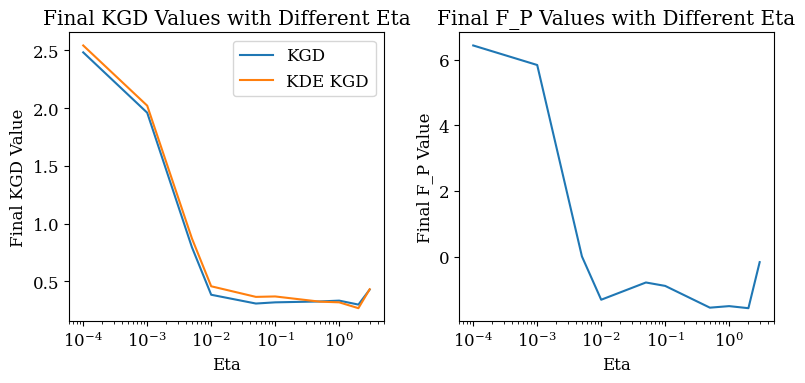

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin,label ='KGD')
axes[0].plot(Eta, KDE_KGD_fin,label='KDE KGD')
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')
axes[0].legend()

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')   
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

plt.tight_layout()
plt.show()


# 2. Linear + Quadratic term 

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x) + \int \int w(x,x') \ d Q(x) d Q(x)$, with $v(x) = 1/2 \|x\|^2$ and $w(x,x') = x^Tx'$.

<!-- if w= 0
F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->

In [45]:
c = jnp.array(1.0)
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) / jnp.sqrt((2  *jnp.pi)**d)
def v(x):
    return -1/4 * jnp.linalg.norm(x,axis = 1)**2
def w(X):
    _X = jax.lax.stop_gradient(X).T
    return jnp.dot(X,_X)
def L(X):
     return np.mean(v(X)) + np.mean(w(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)

MFLD = MeanFieldLangevinDynamics(q_0,L,k)

In [46]:
T = 500
n = 100 
d = 2
Eta = jnp.array([0.001,0.005,0.01,0.05,0.1,0.2,0.5,1.0,2.0,5.0,10.0])
device = jax.devices(device_name)[0]  
n_sim = 1

all_particles_fin = jax.device_put(jnp.zeros((len(Eta), n, d)), device)

for e, eta in enumerate(Eta):
    for sim in range(n_sim):
        key_init = random.PRNGKey(100 + sim)
        key = random.PRNGKey(200 + sim)
        shape = (n, d)
        X0 = random.normal(key_init, shape) + 5 * jnp.ones((n, d))
        X0 = jax.device_put(X0, device)
        all_particles = MFLD.run_particles(eta, T, X0,key)
    
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])

In [47]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
L_fin = jax.device_put(jnp.zeros(len(Eta)), device)

for e in range(len(Eta)):
    X = all_particles_fin[e] 
    KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
    KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X))
    F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X))
    L_fin = L_fin.at[e].set(L(X))

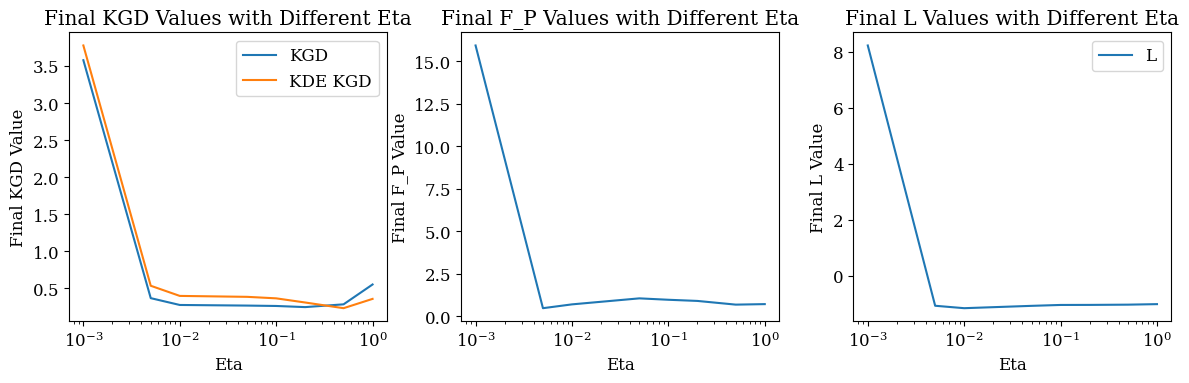

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin,label='KGD')
axes[0].plot(Eta, KDE_KGD_fin,label='KDE KGD')
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')
axes[0].legend()

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

# Plot the third figure (L_fin)
axes[2].plot(Eta, L_fin)
axes[2].set_xlabel('Eta')
axes[2].set_ylabel('Final L Value')
axes[2].set_xscale('log')
axes[2].set_title('Final L Values with Different Eta')
axes[2].legend(['L'])


plt.tight_layout()
plt.show()

<!-- In what follows we controll visually that the distribution converges to $\mathcal{N}(0,2 I_d)$. -->

# 3. MMD

### a) Q_1 is a Gaussian
- $\mathcal{L}(Q) = \frac{\gamma}{2} \textrm{MMD}(Q,Q_1)^2$
- $Q_1 = \mathcal{N}(\mu,\Sigma)$ where $\mu = (5,5)$, $\Sigma = I_d$
- Gaussian kernel in the MMD: $l(x,x') = \exp(-\frac{\|x-x'\|^2}{2 \sigma_l^2})$

In [49]:
c = jnp.array(1.0)
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y))) 

x2 = jnp.array([5,5])
def q_0(x):
    return jnp.exp(-jnp.dot(x,x)/(2*4)) / jnp.sqrt((2* 4  *jnp.pi)**d)

sigma_l = 1.0
l = lambda x,y : ker.k_IMQ(x,y,sigma_l) #Gram matrix for gaussian kernel

d = 2
Cov = np.diag(jnp.ones(d))
n1 = 70
mu = 5*np.ones(d)

key = random.PRNGKey(98)  
shape1 = (n1, d)
X1 = random.multivariate_normal(key,mu,Cov,n1)

gamma = 100
def L(X):
    _X = jax.lax.stop_gradient(X)
    return gamma/2 * (np.mean(l(X,_X)) - 2 * np.mean(l(X,X1)) + np.mean(l(X1,X1)))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)

MFLD = MeanFieldLangevinDynamics(q_0,L,k)

In [50]:
T = 500
n = 50
Eta = jnp.logspace(-3,1,10)
n_sim = 1
devise = jax.devices(device_name)[0]  

all_particles_fin = jax.device_put(jnp.zeros((len(Eta), n, d)), device)

for e, eta in enumerate(Eta):
    for sim in range(n_sim):
        key_init = random.PRNGKey(100 + sim)
        key = random.PRNGKey(200 + sim)
        shape = (n, d)
        X0 = random.normal(key_init, shape) + 5 * jnp.ones((n, d))
        X0 = jax.device_put(X0, device)
        all_particles = MFLD.run_particles(eta, T, X0,key)
    
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])


In [51]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
L_fin = jax.device_put(jnp.zeros(len(Eta)), device)

for e in range(len(Eta)):
    X = all_particles_fin[e] 
    KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
    KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X))
    F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X))
    L_fin = L_fin.at[e].set(L(X))

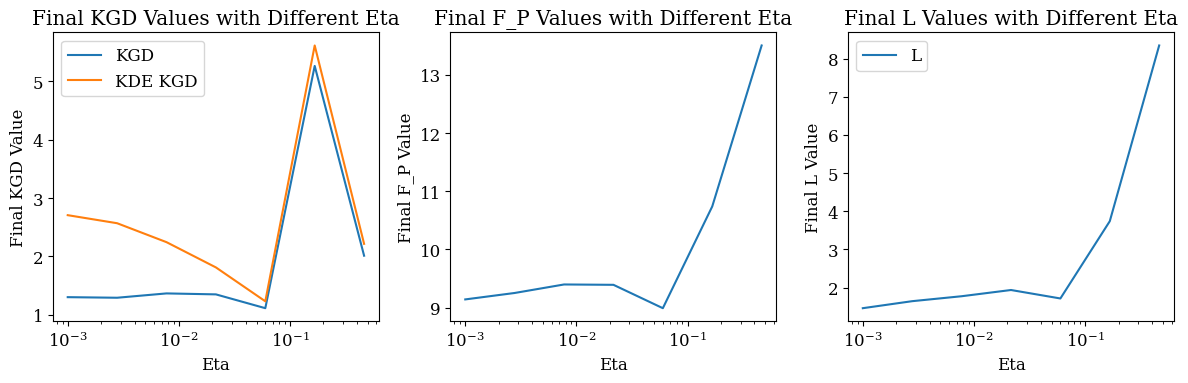

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  

axes[0].plot(Eta, KGD_fin, label='KGD')
axes[0].plot(Eta, KDE_KGD_fin, label='KDE KGD')
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')
axes[0].legend()


axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

axes[2].plot(Eta, L_fin)
axes[2].set_xlabel('Eta')      
axes[2].set_ylabel('Final L Value')
axes[2].set_xscale('log')
axes[2].set_title('Final L Values with Different Eta')
axes[2].legend(['L'])


plt.tight_layout()
plt.show()

Final particles postition : 

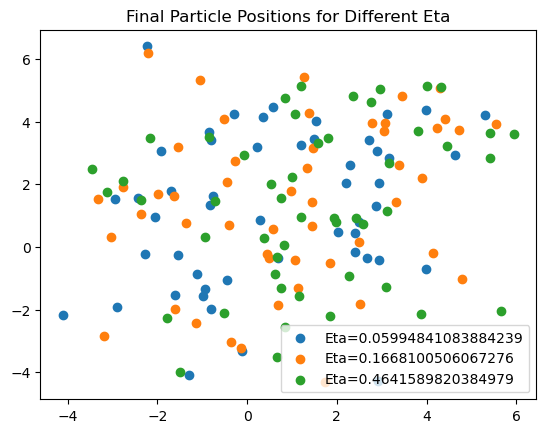

In [15]:
for e in range(4,len(Eta)-3):
    plt.scatter(all_particles_fin[e,:,0], all_particles_fin[e,:,1], label=f'Eta={Eta[e]}')
plt.title('Final Particle Positions for Different Eta')
plt.legend()

# 4 MFNN 
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [3]:
import sys
import os

# Ajoute le dossier parent de `experiments` au path
sys.path.append(os.path.abspath("/Users/clementinechazal/Documents/these/Newcastle/kgd_code"))

import numpy as np
import matplotlib.pyplot as plt
#from kgd_code import mfld
from modules.mfld import MeanFieldLangevinDynamics
from modules.kgd_functions import F_P, GradientKernel, KernelGradientDiscrepancy
import time

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random
from jax.flatten_util import ravel_pytree
from jax import grad, random,vmap,tree_util
import matplotlib

In [3]:
device_name = "cpu"

2 layer neural network :

In [9]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

Generation of the data

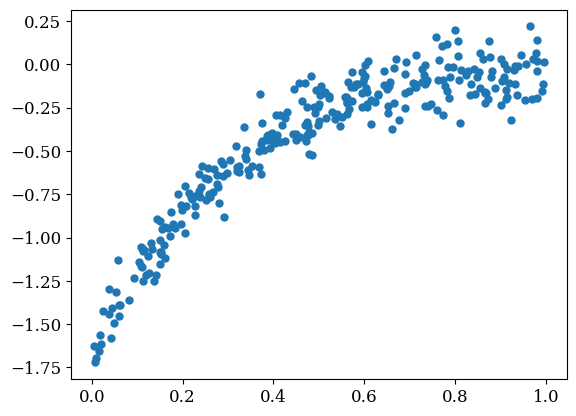

In [10]:

def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [0,1]

    def target_function(z):
        params = jnp.array([2, 0.5, 3, -3])
        return params[2]*jnp.tanh(params[0]*z.squeeze()+params[1]) + params[3]

    Y_clean = target_function(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z_train, Y_train = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
key, subkey = random.split(key)
Z_test, Y_test = generate_data(subkey, s, N=N, noise_std=0.1)

device = jax.devices()[0]
Z_train, Y_train = jax.device_put((Z_train, Y_train), device)
plt.plot(Z_train, Y_train, ".")

$k$, $q_0$ and $\mathcal{L}$

In [ ]:
def k_imq(x, y, c, b, scale=1.):
  assert b > 0
  return (c**2 + (x-y).dot(x-y)/scale**2)**(-b)


k = jit(lambda x, y: k_imq(x, y, 1, 0.5))

def q_0(x):
    return jnp.exp(-jnp.dot(x,x)/2) 

def grad_log_q0(X):
    return - X

def L(X, unravel_fn, Z, Y, gamma=100):
    n = len(X)
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)

gamma = 300
L_ = lambda X: L(X, unravel_fn, Z_train, Y_train, gamma)

k = jit(k)
q_0 = jit(q_0)
L_ = jit(L_)  
 
MFLD = MeanFieldLangevinDynamics(grad_log_q0,L_)    

to do : plot the parameters

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Paramètres
T = 1000
n = 100
nb_runs = 50   # number of runs for statistics
d = len(flat_params)

num_stepsizes = 35
Eta = jnp.logspace(-5, -2.7, num=num_stepsizes)


F_P = F_P(q_0, L_)
k_pq = GradientKernel(MFLD.S_PQ,k)
KGD = KernelGradientDiscrepancy(k_pq)

#array to stock the runs 
KGD_all   = jnp.zeros((nb_runs, len(Eta)))
F_P_all   = jnp.zeros((nb_runs, len(Eta)))
L_all     = jnp.zeros((nb_runs, len(Eta)))

for r in range(nb_runs):
    if r//10 == 0:
        print(f"Run {r+1}/{nb_runs}")

    all_particles_fin = jnp.zeros((len(Eta), n, d))

    for e, eta in enumerate(Eta):
        key = random.PRNGKey(r)
        key, subkey = random.split(key)
        X0 = random.normal(subkey, shape=(n, d))

        all_particles = MFLD.run_particles(eta, T, X0, key)
        all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])

     # Evaulation of the metrics
    KGD_fin = jnp.zeros(len(Eta))
    F_P_fin = jnp.zeros(len(Eta))
    L_fin   = jnp.zeros(len(Eta))
    KGD_KDE_fin = jnp.zeros(len(Eta))

    for e in range(len(Eta)):
        X = all_particles_fin[e]
        KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
        F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X, num_samples=300))
        L_fin   = L_fin.at[e].set(L(X,unravel_fn, Z_test, Y_test, gamma))
        KGD_KDE_fin = KGD_KDE_fin.at[e].set(KGD.kde_KGD(X, num_samples=300))

    
    KGD_all = KGD_all.at[r].set(KGD_fin)
    F_P_all = F_P_all.at[r].set(F_P_fin)
    L_all   = L_all.at[r].set(L_fin)
    KGD_KDE_all = KGD_all.at[r].set(KGD_KDE_fin)

# quantiles
def summary_stats(arr):
    mean = arr.mean(axis=0)
    q10 = jnp.quantile(arr, 0.1, axis=0)
    q90 = jnp.quantile(arr, 0.9, axis=0)
    return mean, q10, q90

KGD_mean, KGD_q10, KGD_q90 = summary_stats(KGD_all)
F_P_mean, F_P_q10, F_P_q90 = summary_stats(F_P_all)
L_mean, L_q10, L_q90       = summary_stats(L_all)
KGD_KDE_mean, KGD_KDE_q10, KGD_KDE_q90 = summary_stats(KGD_KDE_all)



Run 1/50
Run 2/50
Run 3/50
Run 4/50
Run 5/50
Run 6/50
Run 7/50
Run 8/50
Run 9/50
Run 10/50
Run 11/50
Run 12/50
Run 13/50
Run 14/50
Run 15/50
Run 16/50
Run 17/50
Run 18/50
Run 19/50
Run 20/50
Run 21/50
Run 22/50
Run 23/50
Run 24/50
Run 25/50
Run 26/50
Run 27/50
Run 28/50
Run 29/50
Run 30/50
Run 31/50
Run 32/50
Run 33/50
Run 34/50
Run 35/50
Run 36/50
Run 37/50
Run 38/50
Run 39/50
Run 40/50
Run 41/50
Run 42/50
Run 43/50
Run 44/50
Run 45/50
Run 46/50
Run 47/50
Run 48/50
Run 49/50
Run 50/50


In [9]:
import csv

# Recalculer les bonnes statistiques
KGD_mean, KGD_q10, KGD_q90 = summary_stats(KGD_all)
F_P_mean, F_P_q10, F_P_q90 = summary_stats(F_P_all)
L_mean, L_q10, L_q90 = summary_stats(L_all)
KGD_KDE_mean, KGD_KDE_q10, KGD_KDE_q90 = summary_stats(KGD_KDE_all)

#Sauvegarder correctement
with open("/tmp/summary_stats.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Variable", "Mean", "Q10", "Q90"])
    writer.writerow(["KGD", KGD_mean, KGD_q10, KGD_q90])
    writer.writerow(["F_P", F_P_mean, F_P_q10, F_P_q90])
    writer.writerow(["L", L_mean, L_q10, L_q90])
    writer.writerow(["KGD_KDE", KGD_KDE_mean, KGD_KDE_q10, KGD_KDE_q90])

In [4]:
import pandas as pd

df = pd.read_csv("/tmp/summary_stats.csv")

import numpy as np

def str_to_float_array(s):
    return np.fromstring(s.strip('[]'), sep=' ')

# Accès propre avec .iloc[0]
KGD_mean     = str_to_float_array(df.loc[df['Variable'] == 'KGD', 'Mean'].iloc[0])
KGD_q10      = str_to_float_array(df.loc[df['Variable'] == 'KGD', 'Q10'].iloc[0])
KGD_q90      = str_to_float_array(df.loc[df['Variable'] == 'KGD', 'Q90'].iloc[0])

# F_P
F_P_mean     = str_to_float_array(df.loc[df['Variable'] == 'F_P', 'Mean'].iloc[0])
F_P_q10      = str_to_float_array(df.loc[df['Variable'] == 'F_P', 'Q10'].iloc[0])
F_P_q90      = str_to_float_array(df.loc[df['Variable'] == 'F_P', 'Q90'].iloc[0])

# L
L_mean       = str_to_float_array(df.loc[df['Variable'] == 'L', 'Mean'].iloc[0])
L_q10        = str_to_float_array(df.loc[df['Variable'] == 'L', 'Q10'].iloc[0])
L_q90        = str_to_float_array(df.loc[df['Variable'] == 'L', 'Q90'].iloc[0])

# KGD_KDE
KGD_KDE_mean = str_to_float_array(df.loc[df['Variable'] == 'KGD_KDE', 'Mean'].iloc[0])
KGD_KDE_q10  = str_to_float_array(df.loc[df['Variable'] == 'KGD_KDE', 'Q10'].iloc[0])
KGD_KDE_q90  = str_to_float_array(df.loc[df['Variable'] == 'KGD_KDE', 'Q90'].iloc[0])

In [ ]:
import matplotlib
# font options
font = {
#     'family' : 'normal',
    #'weight' : 'bold',
    'size'   : 22
}
matplotlib.rc('font', **{'family': 'serif', })
plt.rc('font', **font)
plt.rc('lines', linewidth=3, markersize=10)
matplotlib.rcParams['ps.useafm'] = True
matplotlib.rcParams['pdf.use14corefonts'] = True
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [26]:
# # font options
# font = {
# #     'family' : 'normal',
#     #'weight' : 'bold',
#     'size'   : 22
# }
# matplotlib.rc('font', **{'family': 'serif', })


# # matplotlib.use('cairo')
# matplotlib.rc('text', usetex=True)
# #matplotlib.rcParams['text.usetex'] = True
# plt.rc('font', **font)
# plt.rc('lines', linewidth=3, markersize=10)
# # matplotlib.rcParams['ps.useafm'] = True
# # matplotlib.rcParams['pdf.use14corefonts'] = True

# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['ps.fonttype'] = 42

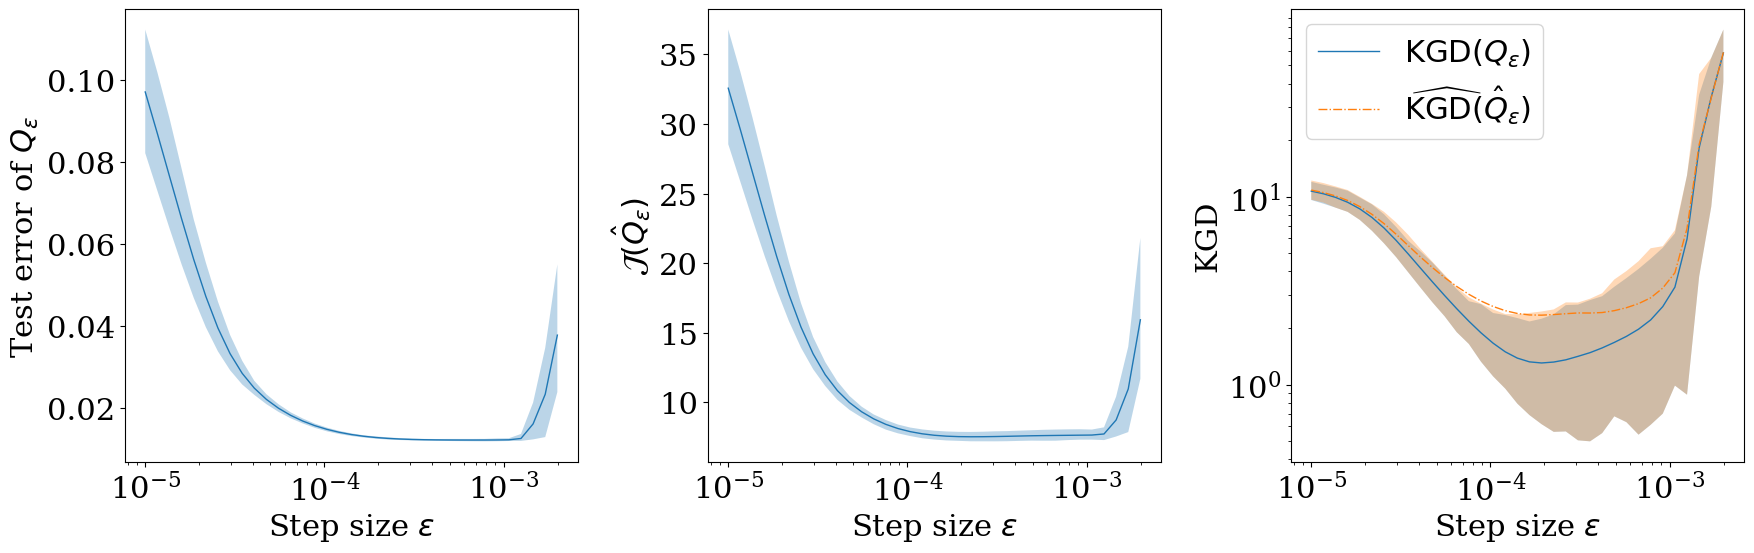

In [27]:
import seaborn as sns
colors = sns.color_palette("colorblind")
#plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

# Generalisation error (MSE)
axes[0].plot(Eta, (1/gamma) * L_mean, label="L (mean)")
axes[0].fill_between(Eta, (1/gamma) * L_q10, (1/gamma) * L_q90, alpha=0.3)
axes[0].set_xscale("log")
axes[0].set_xlabel(r'Step size $\epsilon$')
axes[0].set_ylabel(r'Test error of $Q_\epsilon$')
#axes[0].set_title("MSE Final vs. Eta")

# F_P
axes[1].plot(Eta, F_P_mean, label="F_P (mean)")
axes[1].fill_between(Eta, F_P_q10, F_P_q90, alpha=0.3)
axes[1].set_xscale("log")
axes[1].set_xlabel(r'Step size $\epsilon$')
axes[1].set_ylabel(r'$\mathcal{J}(\hat{Q}_\epsilon)$')
#axes[1].set_title(r"$\mathcal{F}_P$ Final vs. $\eta$")

# KGD
axes[2].plot(Eta, KGD_mean, label=r'$\mathrm{KGD}(Q_\epsilon)$')
axes[2].fill_between(Eta, KGD_q10, KGD_q90, alpha=0.3)
axes[2].plot(Eta, KGD_KDE_mean, linestyle='-.', label=r'$\widehat{\mathrm{KGD}}(\hat{Q}_\epsilon)$')
axes[2].fill_between(Eta, KGD_KDE_q10, KGD_KDE_q90, alpha=0.3)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel(r'Step size $\epsilon$')
axes[2].set_ylabel('KGD')
#axes[0].set_title(r"KGD Final vs. $\eta$")
axes[2].legend()

plt.tight_layout()
#plt.savefig("final_metrics_plot.pdf", bbox_inches='tight')

In [22]:
# Check if the best stepsize is the same for KGD and F_P
e_min_KGD = jnp.argmin(KGD_mean[:-1])
e_min_F_P = jnp.argmin(F_P_mean[:-1])
print(f"Best Eta for KGD: {Eta[e_min_KGD]:.4f}")
print(f"Best Eta for F_P: {Eta[e_min_F_P]:.4f}")


Best Eta for KGD: 0.0002
Best Eta for F_P: 0.0002


Plot of the predictions

/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_72332/2353318549.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


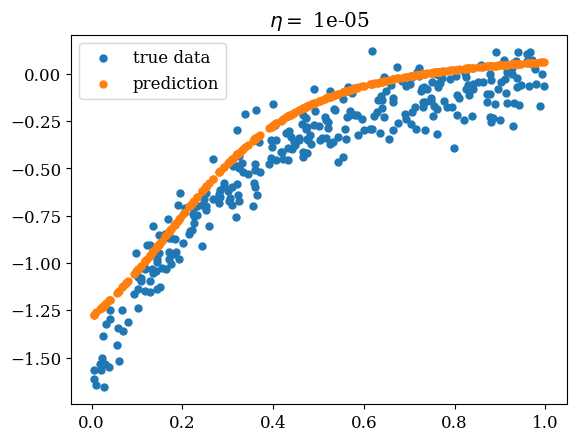

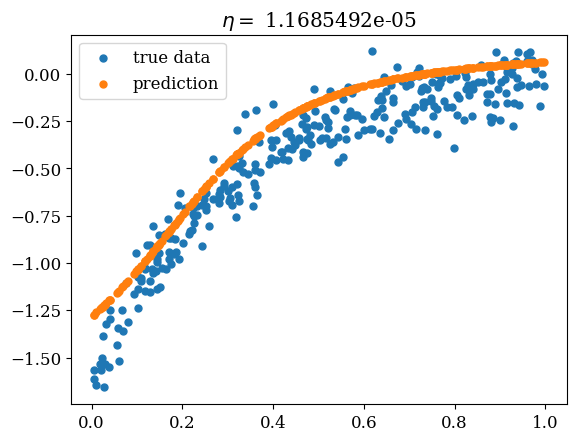

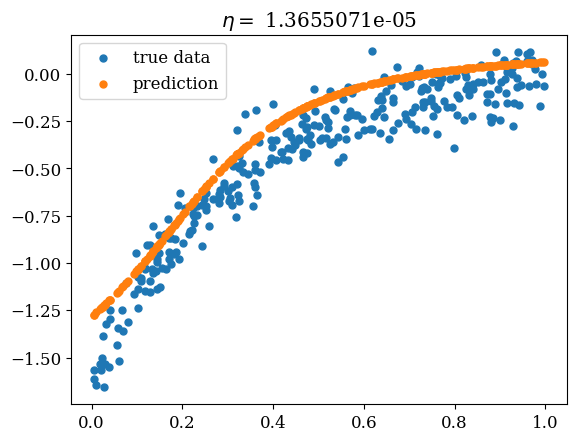

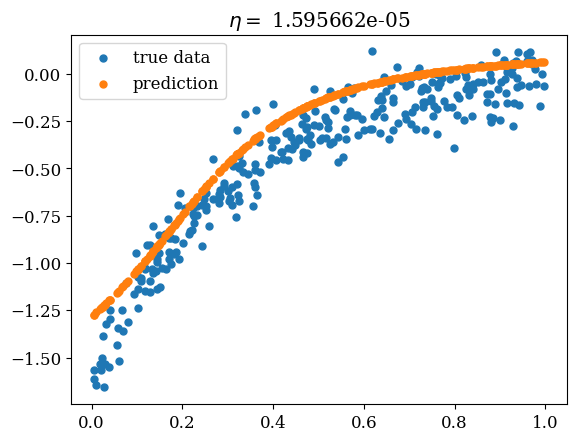

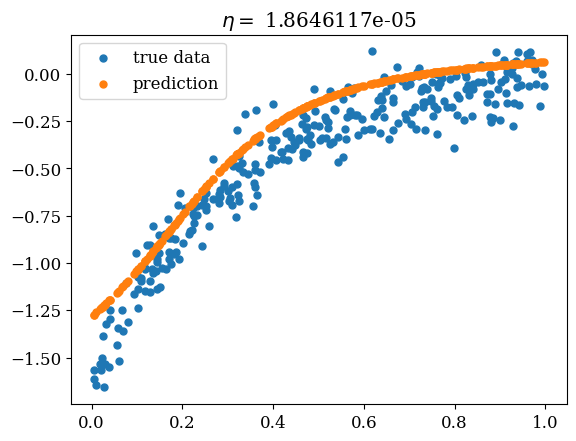

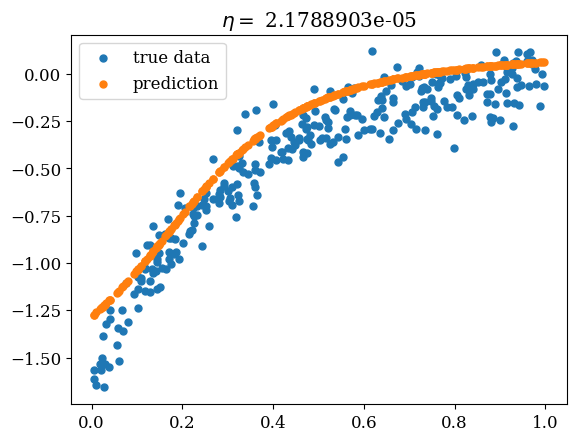

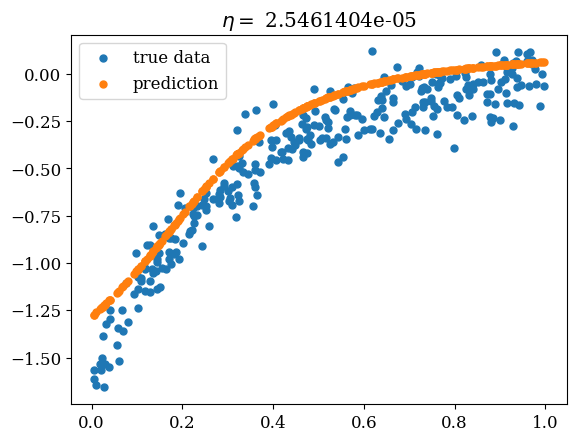

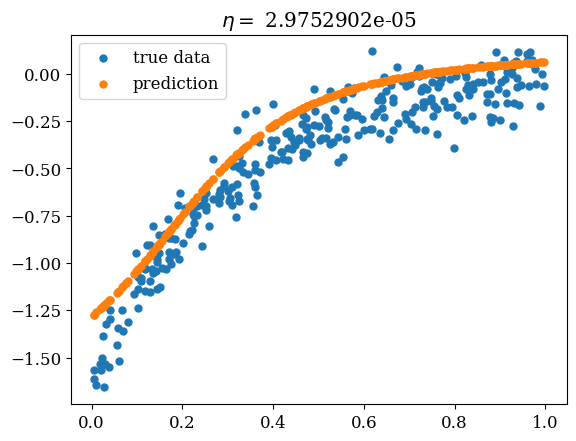

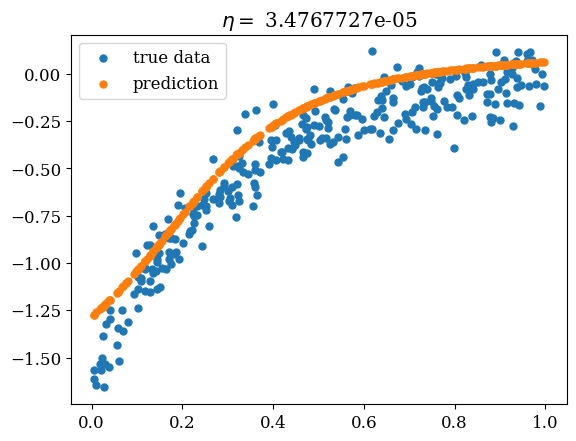

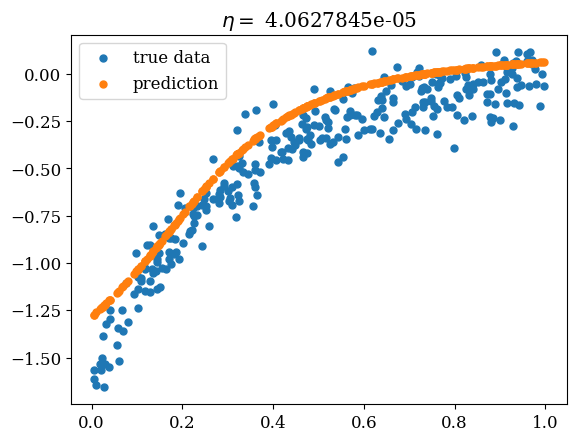

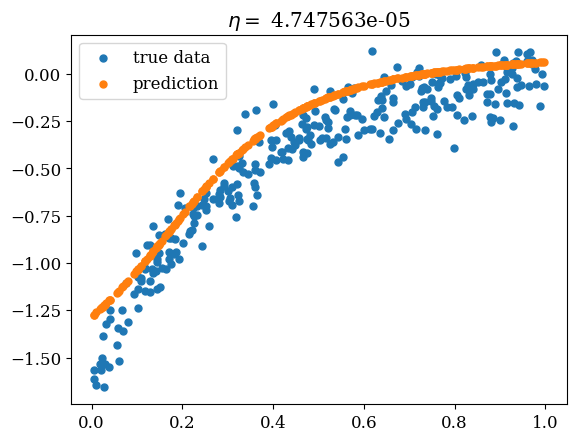

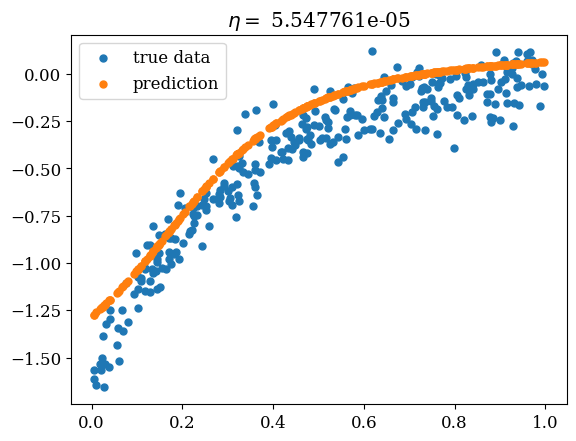

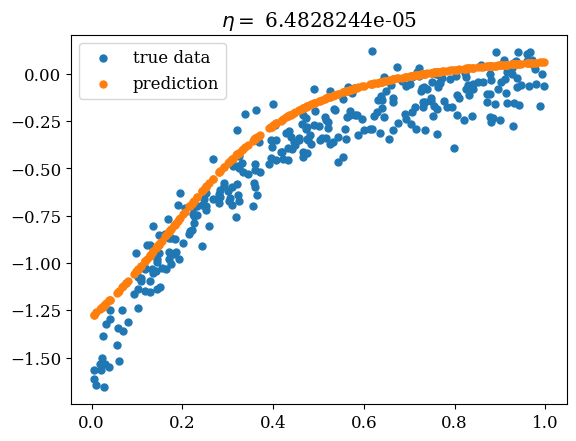

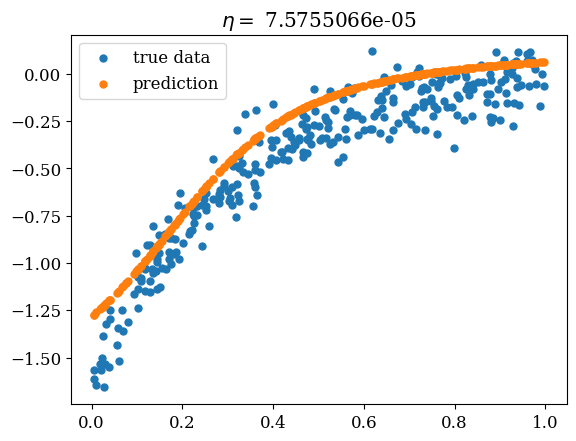

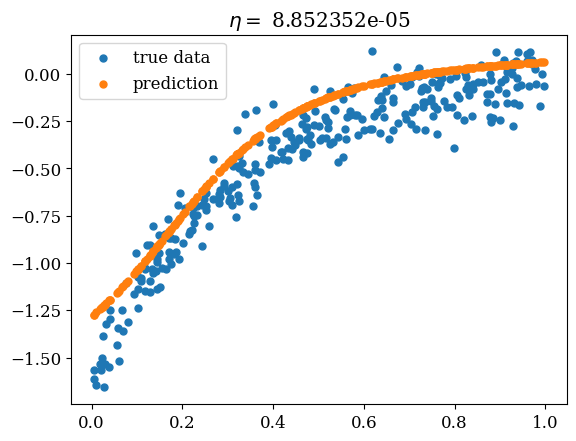

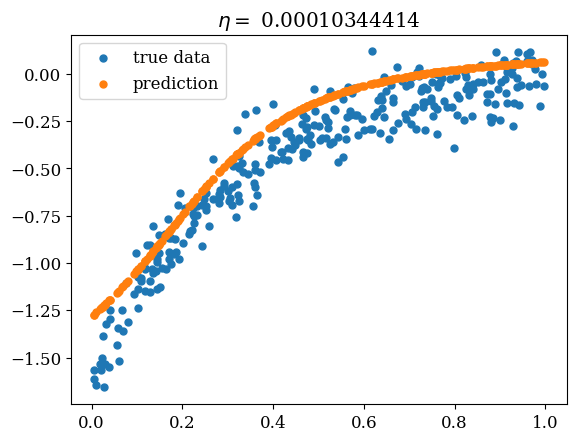

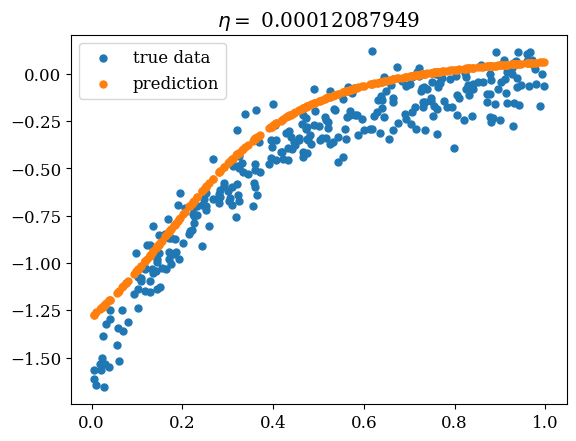

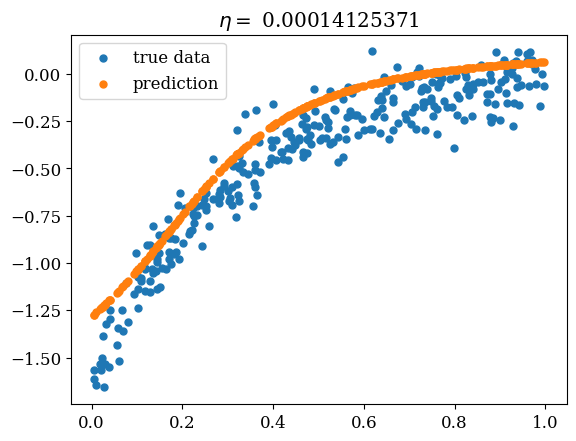

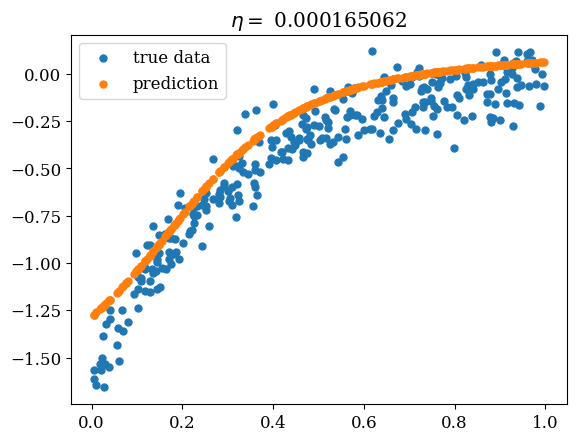

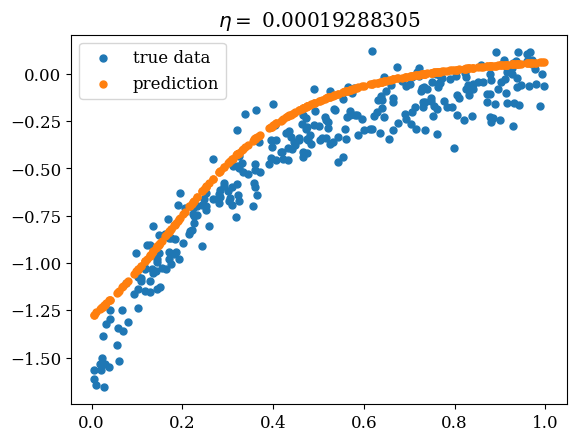

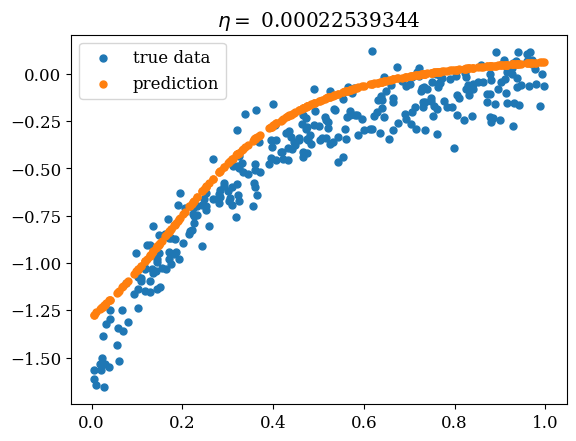

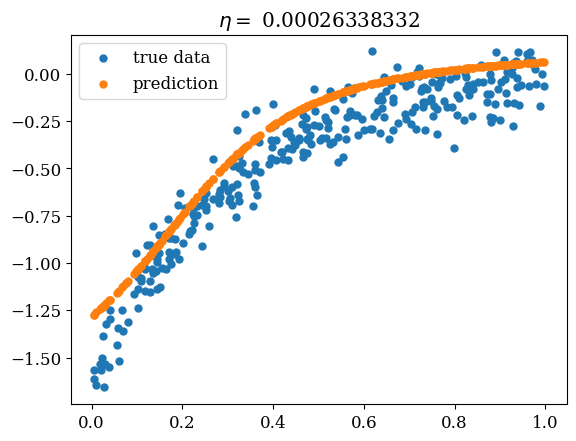

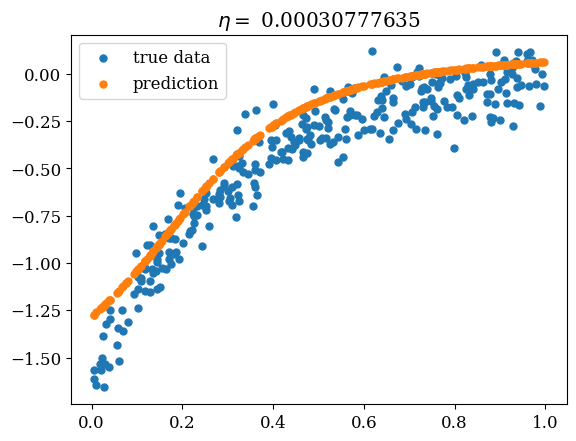

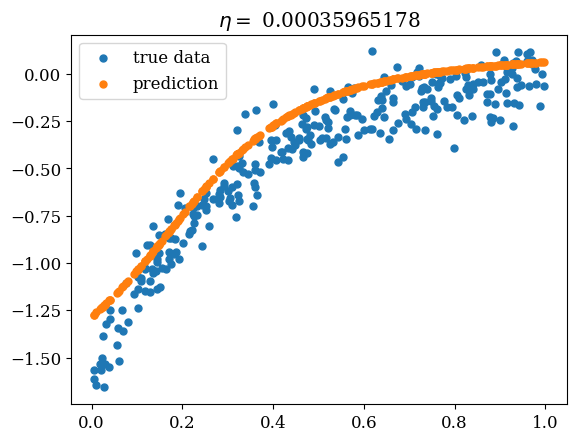

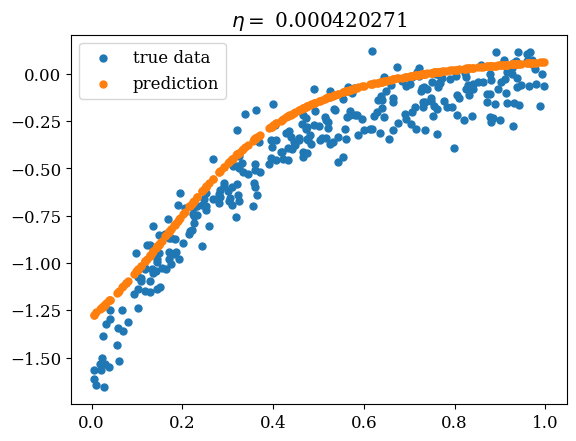

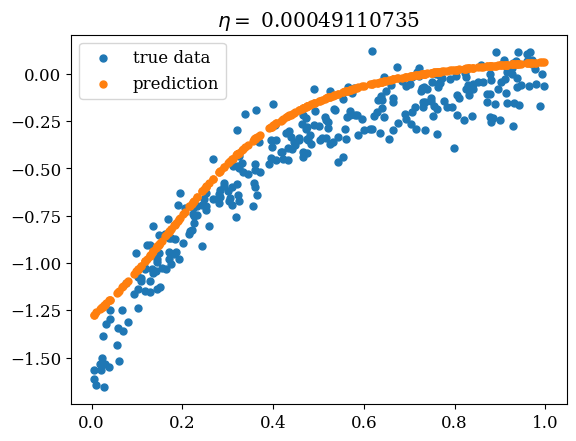

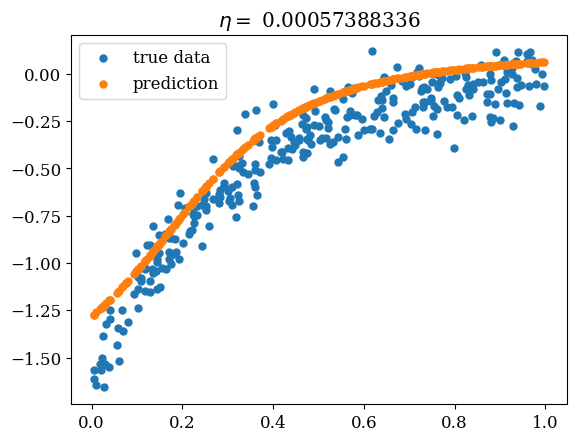

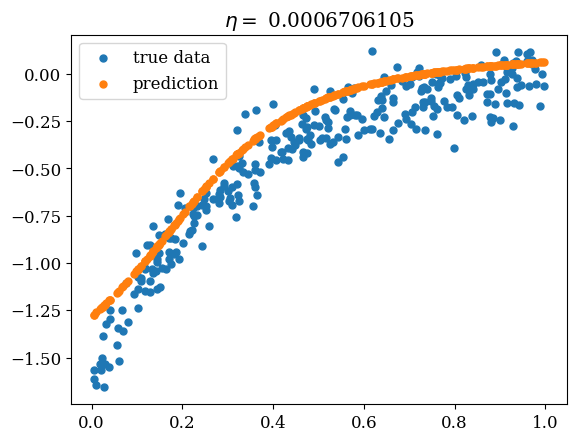

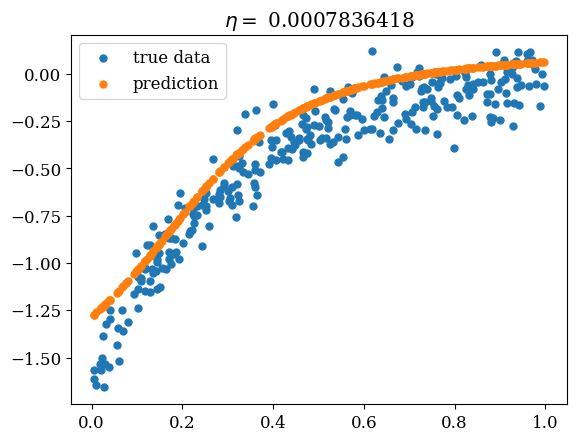

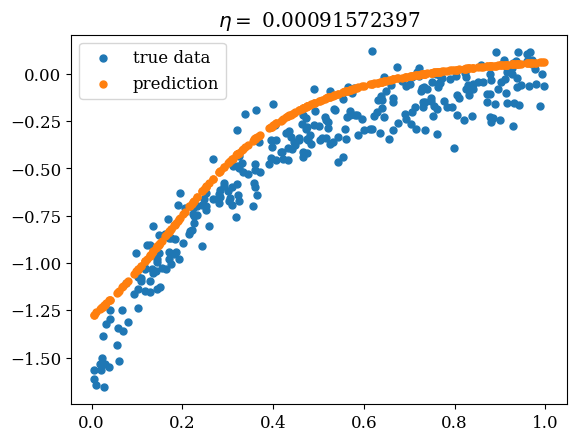

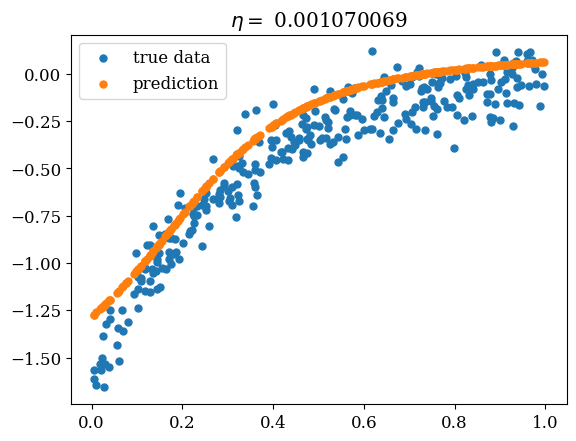

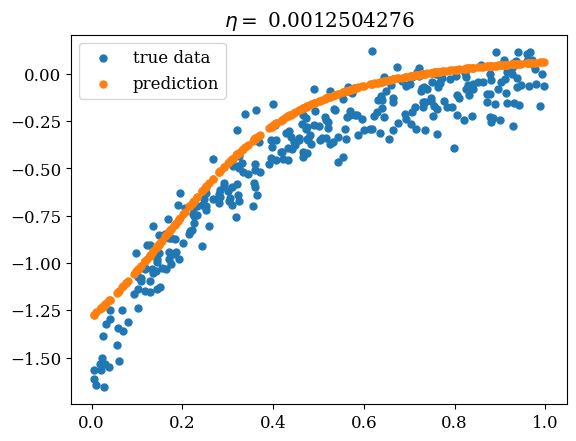

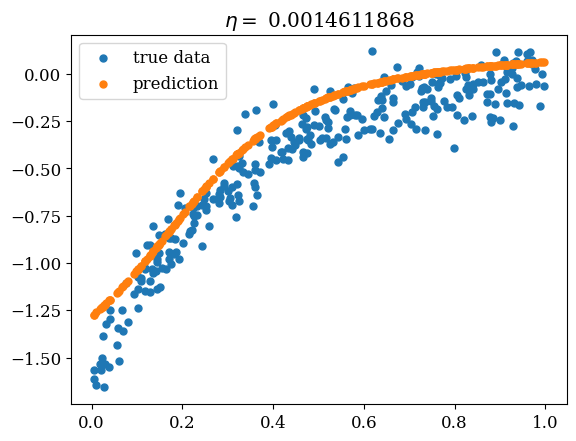

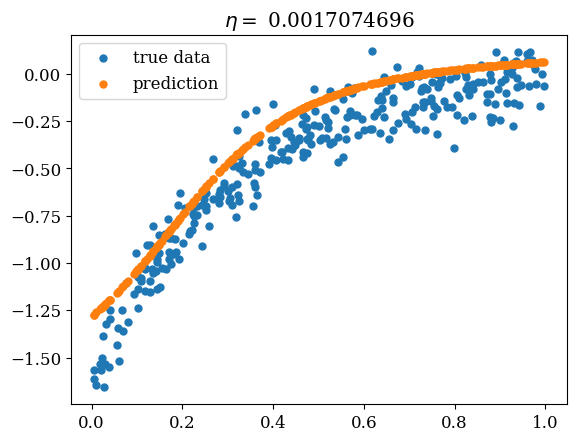

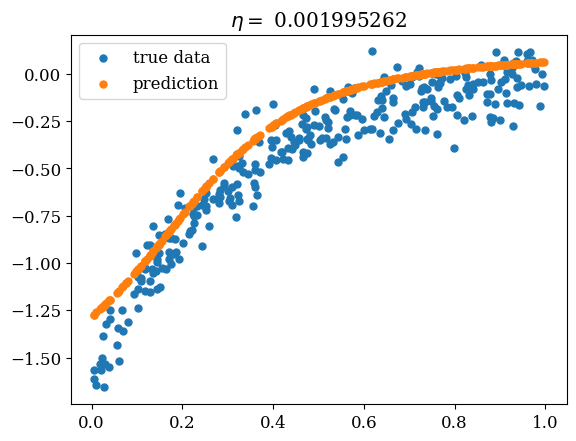

In [ ]:
for e in range(len(Eta)):
    plt.figure()
    plt.scatter(Z_test,Y_test,label = "true data",marker = ".")
    X_fin = all_particles_fin[e]
    Y_hat = vmap(lambda z: forward_(X_fin, z, unravel_fn))(Z_test)
    plt.scatter(Z_test,Y_hat,label = "prediction",marker = ".")
    plt.legend()
    plt.title(r"$\eta = $ " + str(Eta[e]))
